# **MÓDULO 20 - Projeto de Credit Score - Naive Bayes**


## Objetivo

Aplicaremos o algoritmo de naive bayes a base de treino e teste para tentarmos trazer previsões do score de crédito.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score
import plotly.figure_factory as ff

# 1 Carrega as bases de treino (X e y) e teste (X e y).

In [2]:
X_test = pd.read_csv("X_test.csv", delimiter=';')
X_train = pd.read_csv("X_train_balanced.csv", delimiter=';')
y_test = pd.read_csv("y_test.csv", delimiter=';')
y_train = pd.read_csv("y_train_balanced.csv", delimiter=';')

In [3]:
# Vizualiza os dados de teste da base X teste
X_test.head()

,Age,Income,Number of Children,Education_encoded,Gender_Masculino,Marital Status_Solteiro(a),Home Ownership_Próprio
0,37,75.0,2,2,0,0,1
1,30,105.0,2,3,1,0,1
2,45,110.0,3,2,0,0,1
3,36,95.0,2,3,0,0,1
4,34,47.5,0,1,1,1,0


In [4]:
#  Verifica a quantidade linhas e colunas da base X teste
X_test.shape

(33, 7)

In [5]:
# Vizualiza os dados de treino da base X treino
X_train.head()

,Age,Income,Number of Children,Education_encoded,Gender_Masculino,Marital Status_Solteiro(a),Home Ownership_Próprio
0,33,52.5,0,0,1,1,0
1,48,70.0,1,4,0,0,1
2,26,45.0,0,1,0,1,0
3,50,155.0,0,3,1,0,1
4,36,140.0,0,2,1,0,1


In [6]:
#  Verifica a quantidade linhas e colunas da base X treino
X_train.shape

(270, 7)

In [7]:
# Vizualiza os dados de teste da base y teste
y_test.head()

,credit_score_encoded
0,2
1,2
2,2
3,2
4,1


In [8]:
#  Verifica a quantidade linhas e colunas da base y teste
y_test.shape

(33, 1)

In [9]:
# Vizualiza os dados de treino da base y treino
y_train.head()

,credit_score_encoded
0,1
1,2
2,1
3,2
4,2


In [10]:
#  Verifica a quantidade linhas e colunas da base y treino
y_train.shape

(270, 1)

In [11]:
map_score = {
    0: 'Baixo',
    1: 'Médio',
    2: 'Alto'
}

# Contar o número de exemplos de cada classe em y_train
train_balance = y_train['credit_score_encoded'].map(map_score).value_counts().sort_index()
print("Balanceamento em y_train:")
print(train_balance)

# Contar o número de exemplos de cada classe em y_test
test_balance = y_test['credit_score_encoded'].map(map_score).value_counts().sort_index()
print("\nBalanceamento em y_test:")
print(test_balance)

Balanceamento em y_train:
credit_score_encoded
Alto     90
Baixo    90
Médio    90
Name: count, dtype: int64

Balanceamento em y_test:
credit_score_encoded
Alto     23
Baixo     3
Médio     7
Name: count, dtype: int64


# 2 Algoritmo de Naive Bayes aos dados de treinamento

In [12]:
y_train = y_train['credit_score_encoded']
y_test = y_test['credit_score_encoded']

In [13]:
# Criação de uma instância do classificador Naive Bayes Gaussiano
naive_credit_score = GaussianNB()
# Treinamento do classificador usando os dados de treinamento
naive_credit_score.fit(X_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


# 3 Avaliação do modelo com os dados de treinamento.

In [14]:
# Fazendo previsões com os dados de treinamento
y_predict_train = naive_credit_score.predict(X_train)

# Calculando a acurácia
accuracy_train = accuracy_score(y_train, y_predict_train)

# Calculando o recall
recall_train = recall_score(y_train, y_predict_train, average='macro')

print(f"Acurácia no treino: {accuracy_train:.4f}")
print(f"Recall macro no treino: {recall_train:.4f}")

Acurácia no treino: 0.9556
Recall macro no treino: 0.9556


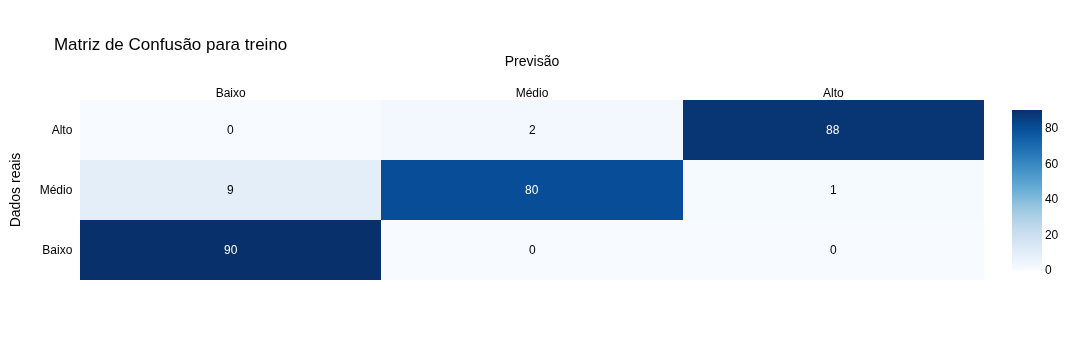

In [15]:
# Criando a matrix de confusão para os dados de treino
confusion_matrix_train = confusion_matrix(y_train, y_predict_train)

# Definindo nomes de classes
class_names = ['Baixo', 'Médio', 'Alto']

# Plotando a matriz de confusão com Plotly
fig = ff.create_annotated_heatmap(
    z=confusion_matrix_train,
    x=class_names,
    y=class_names,
    colorscale='Blues',
    showscale=True
)
fig.update_layout(
    title='Matriz de Confusão para treino',
    xaxis_title='Previsão',
    yaxis_title='Dados reais',
    font=dict(
        family='Arial',
        size=12,
        color='black'
    )
)

Vemos um bom desempenho do modelo com os dados de treino, com valores de acurácia e recall muito alta. POdemos perceber que os dois que as duas medidas obtevc valores iguais, isso significa que a maioria das previsões foram verdadeiras.

# 4 Avaliação do modelo com os dados de teste

In [16]:
#seu código aqui# Fazendo previsões com os dados de teste
y_predict_test = naive_credit_score.predict(X_test)

# Calculando a acurácia
accuracy_test = accuracy_score(y_test, y_predict_test)

# Calculando o recall macro
recall_test = recall_score(y_test, y_predict_test, average='macro')

print(f"Acurácia no teste: {accuracy_test:.4f}")
print(f"Recall macro no teste: {recall_test:.4f}")

Acurácia no teste: 0.9394
Recall macro no teste: 0.9379


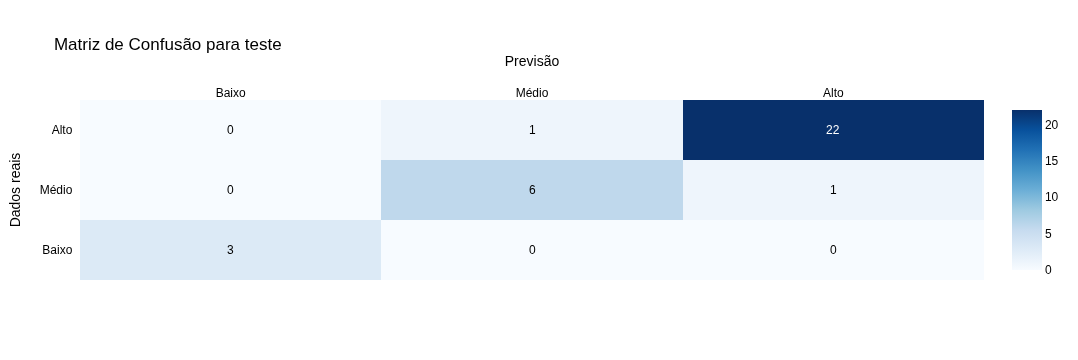

In [17]:
# Criando a matrix de confusão para os dados de teste
confusion_matrix_test = confusion_matrix(y_test, y_predict_test,)

# Definindo nomes de classes
class_names = ['Baixo', 'Médio', 'Alto']

# Plotando a matriz de confusão com Plotly
fig = ff.create_annotated_heatmap(
    z=confusion_matrix_test,
    x=class_names,
    y=class_names,
    colorscale='Blues',
    showscale=True
)
fig.update_layout(
    title='Matriz de Confusão para teste',
    xaxis_title='Previsão',
    yaxis_title='Dados reais',
    font=dict(
        family='Arial',
        size=12,
        color='black'
    )
)

É possível perceber que os resultados de acurácia e recall foram um pouco menores nos dados de teste em comparação com os dados de treino. Isso indica uma pequena queda de desempenho ao aplicar o modelo em dados novos. Mesmo assim, como os valores continuam altos, o modelo apresentou boa capacidade de generalização, não havendo sinais fortes de overfitting.

## 5 Comparação entre treino e teste

In [19]:
resultados = pd.DataFrame({
    'Base': ['Treino', 'Teste'],
    'Acurácia': [accuracy_train, accuracy_test],
    'Recall Macro': [recall_train, recall_test]
})

resultados

,Base,Acurácia,Recall Macro
0,Treino,0.955556,0.955556
1,Teste,0.939394,0.937888


Ao comparar os resultados, observamos que o modelo apresentou acurácia de 0,9556 no treino e 0,9394 no teste. O recall macro também foi próximo nas duas bases, com 0,9556 no treino e 0,9379 no teste. Essa pequena diferença indica que o modelo teve bom desempenho nos dados de treinamento e conseguiu manter uma boa capacidade de generalização nos dados de teste.

# 6 Considerações Finais

Neste projeto, aplicamos o algoritmo Naive Bayes para prever a classificação do score de crédito em três categorias: Baixo, Médio e Alto, utilizando bases de treino e teste já tratadas, com variáveis numéricas e categóricas codificadas. O modelo apresentou bom desempenho nos dados de treino, com acurácia de 0,9556 e recall macro de 0,9556, e também obteve bons resultados nos dados de teste, com acurácia de 0,9394 e recall macro de 0,9379. Apesar de os resultados do teste terem sido um pouco inferiores aos do treino, a diferença foi pequena, indicando que o modelo conseguiu generalizar bem para dados novos. Portanto, o objetivo principal da atividade foi alcançado, pois conseguimos treinar, avaliar e interpretar um modelo Naive Bayes aplicado a um problema de classificação multiclasse de score de crédito.